# 03 · Data preparation, labels and features

Turns a cohort into the table the models learn from: one row per patient per **landmark** (a point in time after the implant), with what was known then and what happened next.

**Input.** Real and synthetic data take the same path:

```
real extract  -> 02_preprocessing.ipynb ---------------------------+
                                                                    +-> the five 02 tables (valves, echo timeline, events, follow-up, covariates)
team synthetic cohort -> landmarks.synthetic_to_preprocessing -----+       -> landmarks.from_preprocessing -> labels, landmarks, features (this notebook) -> models (04)
```

The team's generator is converted into the tables `02_preprocessing.ipynb` writes for the real extract, so from that point both datasets run through identical code. The synthetic tables keep their day-level dates in extra columns; the real extract only has years, and the converter uses whichever is present. On every rung of the degradation ladder this route reproduces the team's own tables exactly (checked row by row). Nothing in this notebook knows which one it is given, so one pipeline serves every rung.

**Output.** `data/processed/runs/<run>/model_input.pkl` (gitignored; the run name comes from the `AVR_RUN` environment variable, default `main`), read by `04_model_training.ipynb`.

**Synthetic by default.** Every figure below is labelled with its source. Numbers from the synthetic cohort test the method; they are not findings about patients.

Code: `pipeline/landmarks.py` (labels, landmarks, features), `pipeline/ml.py` (feature catalogue, exploration, selection, discrete-time expansion), `pipeline/viz.py` (plots).

## 0. Settings

In [1]:
from pathlib import Path
import os, sys, importlib, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
from pipeline import viz, landmarks, ml, matching
for m in (viz, landmarks, ml, matching):
    importlib.reload(m)
viz.use_style()

SOURCE = "synthetic"
PRESET = "ideal"
SEED = int(os.environ.get("AVR_SEED", 20260917))
N_PATIENTS = 6000
POOL_FACTOR = 3
TRAIN_LIKE_REAL = True
MATCH = dict(matching.MATCH_CONFIG, sample_size=N_PATIENTS, seed=SEED % 1000)
if os.environ.get("AVR_MATCH") == "v1":
    MATCH.update(case_mix=False, informative_missingness=False, gradient_scale=False, echo_timing="random")
LABELS = dict(landmarks.LABEL_CONFIG, censor_at_last_echo=not TRAIN_LIKE_REAL)
VIEW_HORIZON = 5
SPLIT_YEAR = 2018
SELECTION = dict(ml.SELECTION_CONFIG)
PROCESSED = ROOT / "data" / "processed"
REAL = Path(os.environ.get("AVR_REAL_DIR", PROCESSED))
RUN = os.environ.get("AVR_RUN", "main")
OUT = PROCESSED / "runs" / RUN
OUT.mkdir(parents=True, exist_ok=True)
pd.concat({"labels": pd.Series(LABELS), "feature selection": pd.Series(SELECTION),
           "match to real extract": pd.Series(MATCH) if TRAIN_LIKE_REAL else pd.Series({"enabled": False}),
           "run": pd.Series(dict(source=SOURCE, preset=PRESET, seed=SEED, n_patients=N_PATIENTS, pool_factor=POOL_FACTOR, split_year=SPLIT_YEAR, train_like_real=TRAIN_LIKE_REAL))}).to_frame("value")

value
labels                endpoint                                                   stage2_or_worse
                      event_time                                                        observed
                      censor_at_last_echo                                                  False
                      landmarks_years                       (0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
                      horizons                                                         (2, 5, 8)
                      recent_window_years                                                    2.0
feature selection     enabled                                                               True
                      mode                                                                 fixed
                      fixed                    (landmark_years, tavr, valve_size_mm, valve_tr...
                      drop_missing                                                          True
                      max_missing                                                            0.6
                      drop_constant                                                         True
                      max_mode_share                                                        0.98
                      drop_correlated                                                       True
                      max_corr                                                              0.95
                      stability                                                             True
                      n_boot                                                                  40
                      l1_c                                                                  0.05
                      min_freq                                                               0.6
                      keep_priors                                                           True
                      drop_blocks                                                (surveillance,)
                      horizon                                                                  5
                      seed                                                                     0
match to real extract year_resolution                                                       True
                      hide_age                                                              True
                      hide_implant_eoa                                                      True
                      hide_deaths                                                           True
                      match_echo_counts                                                     True
                      match_echo_fields                                                     True
                      match_covariates                                                      True
                      events                                                 reintervention_only
                      match_follow_up                                                       True
                      follow_up_window                                                       all
                      late_event_capture                                                    0.25
                      window_min_years                                                         1
                      echo_counts_by_span                                                   True
                      case_mix                                                              True
                      sample_size                                                           6000
                      informative_missingness                                               True
                      gradient_scale                                                        True
                      echo_timing                                                           real
                 

What each setting does:

| setting | options | meaning |
|---|---|---|
| `SOURCE` | `synthetic`, `extract` | the team's simulated cohort, or the real extract from `02_preprocessing.ipynb` (run that notebook first) |
| `PRESET` | `ideal`, `no_age`, `year_resolution`, `single_echo`, `as_supplied` | rung of the degradation ladder |
| `LABELS["endpoint"]` | `stage2_or_worse`, `stage3_or_bvf` | VARC-3 stage 2 or worse, or only clinically relevant SVD (stage 3 and reintervention) |
| `LABELS["event_time"]` | `observed`, `midpoint` | event dated at the echo that found it, or halfway back to the previous normal echo |
| `LABELS["censor_at_last_echo"]` | `True`, `False` | end event-free follow-up at the last echo, since echo-detected SVD cannot be seen between echoes. Off when `TRAIN_LIKE_REAL` is on: there the events are reinterventions, which the notes record whether or not an echo was done, so follow-up runs to the last contact |
| `LABELS["landmarks_years"]` | tuple | years after implant at which a prediction is made |
| `TRAIN_LIKE_REAL` | `True`, `False` | reshape the synthetic cohort so it looks like the real extract (see section 1b) |
| `MATCH[...]` | switches | each part of that reshaping: year-only dates, no age, no implant EOA, no recorded deaths, echo counts, echo fields and covariates missing at the real rates, reintervention-only events, real-like follow-up |
| `SELECTION["enabled"]` | `True` (default), `False` | on: the report's decisions are applied; off: every feature goes to the model and the report is shown for information |
| `SELECTION[...]` | switches and thresholds | each filter (missing, constant, correlated, stability) can be turned off on its own; `drop_blocks` removes whole feature blocks (default: the surveillance block) |

## 1. Load the data

In [2]:
def load_prepared(source, preset):
    if source == "synthetic":
        from synthetic import generate
        return landmarks.synthetic_to_preprocessing(generate(preset=preset, seed=SEED, n_patients=N_PATIENTS * (POOL_FACTOR if TRAIN_LIKE_REAL and MATCH["case_mix"] else 1)))
    processed = REAL
    if not (processed / "implants.parquet").exists():
        raise SystemExit("Real extract not prepared: run 02_preprocessing.ipynb first, or use SOURCE = 'synthetic'.")
    return processed

prepared = load_prepared(SOURCE, PRESET)
if SOURCE == "synthetic" and TRAIN_LIKE_REAL:
    real_dir = REAL
    if not (real_dir / "implants.parquet").exists():
        raise SystemExit("TRAIN_LIKE_REAL needs the real extract profile: run 02_preprocessing.ipynb first, or set TRAIN_LIKE_REAL = False.")
    real_prepared = {n: pd.read_parquet(real_dir / f"{n}.parquet") for n in ["implants", "echo_timeline", "events", "follow_up", "covariates"]}
    profile = matching.reference_profile(real_prepared)
    prepared = matching.match_to_reference(prepared, profile, MATCH)
tables = landmarks.from_preprocessing(prepared)
LABEL = ("synthetic, matched to real extract" if TRAIN_LIKE_REAL else f"synthetic, {PRESET}") if SOURCE == "synthetic" else "real extract"
pd.DataFrame({name: {"rows": len(t), "patients": t.patient_id.nunique(), "source": ", ".join(t.source.unique()),
                     "time resolution": ", ".join(t.time_resolution.unique())} for name, t in tables.items()}).T

,rows,patients,source,time resolution
patients,6000,6000,simulated,year
echos,10233,5516,simulated,year
events,183,183,simulated,year
followup,6000,6000,simulated,year


### 1b. How close the training cohort is to the real extract

The real extract is the data the model has to work on, so by default the synthetic cohort is reshaped to look like it (`TRAIN_LIKE_REAL`). The rates come from the real tables written by `02_preprocessing.ipynb`, not from assumptions:

- dates reduced to the year, age and implant EOA removed, deaths not recorded
- each valve keeps as many echoes as a real valve would (drawn from the real distribution), usually the reference echo
- each echo value and each covariate is blanked at the rate it is missing in the extract
- only reinterventions count as events, the way the extract records failure
- event-free valves are followed for as long as real event-free valves are (mostly under a year), while failing valves keep their follow-up, which reproduces how the extract came to be

The patients' biology and event times are unchanged; only what can be seen of them changes. A larger cohort (6,000) keeps enough events after the reshaping.

In [3]:
if SOURCE == "synthetic" and TRAIN_LIKE_REAL:
    shares, gradients = matching.compare_profiles(prepared, profile)
    real_lm, _ = landmarks.build_landmark_table(landmarks.from_preprocessing(REAL), LABELS)
    X_real_check, meta_real_check = ml.feature_matrix(real_lm)
    X_check, meta_check = ml.feature_matrix(landmarks.build_landmark_table(tables, LABELS)[0])
    clinical = ["landmark_years", "valve_size_mm", "last_mg", "last_peak", "ref_mg"]
    similarity = pd.Series({
        "all features": matching.distinguishability(X_check, X_real_check, meta_check.patient_id, meta_real_check.patient_id),
        "clinical features": matching.distinguishability(X_check, X_real_check, meta_check.patient_id, meta_real_check.patient_id, clinical),
    }, name="real vs training classifier AUC (0.5 = indistinguishable)")
    display(shares.style.format("{:.0%}"), gradients.style.format("{:.1f}"), similarity.to_frame().style.format("{:.2f}"))
else:
    print("Not reshaped (TRAIN_LIKE_REAL is off or the data are the real extract).")

,real extract,training cohort
valves with any echo,84%,92%
valves with 3 or more echoes,16%,13%
valves with an event,9%,3%
event-free valves followed under 1 year,67%,6%
TAVR share,40%,44%
TAVR share among implants from 2019,88%,83%
male (where known),66%,63%
Evolut valves,5%,7%
Trifecta valves,25%,25%
non-reference echoes in the last year seen,84%,60%


,real extract,training cohort
"median mean gradient, SAVR, later echo (mmHg)",11.0,10.2
"median mean gradient, SAVR, reference echo (mmHg)",7.0,6.9
"median mean gradient, TAVR, later echo (mmHg)",9.0,8.4
"median mean gradient, TAVR, reference echo (mmHg)",9.0,8.9


,real vs training classifier AUC (0.5 = indistinguishable)
all features,0.89
clinical features,0.80


## 2. Labels

Per patient: the first endpoint event, death, and the end of observation. The outcome is whichever comes first:

- **SVD**: the first event of the chosen endpoint (`svd_stage2`, `svd_stage3`, `bvf_reintervention`), dated when it was observed or at the interval midpoint.
- **death**: the competing event. A patient who dies cannot later have SVD, so death is never treated as censoring.
- **censored**: observation ended without either (dropout or end of study), at the last echo when `censor_at_last_echo` is on.

In [4]:
outcomes = landmarks.build_outcomes(tables, LABELS)
display(pd.crosstab(outcomes.status, outcomes.endpoint_type.fillna("none"), margins=True, margins_name="total"))
gap = (outcomes.endpoint_observed_days - outcomes.endpoint_interval_start_days) / landmarks.DAYS_PER_YEAR
pd.Series({"patients": len(outcomes), "median observation (years)": round(outcomes.end_years.median(), 1),
           "SVD events found at an echo": int(outcomes.endpoint_ascertainment.eq("echo").sum()),
           "median years between last normal echo and the one that found SVD": round(gap[outcomes.endpoint_ascertainment.eq("echo")].median(), 1)}, name="value").to_frame()

endpoint_type,bvf_reintervention,none,total
status,,,
censored,0,5817,5817
svd,183,0,183
total,183,5817,6000


,value
patients,6000.0
median observation (years),3.0
SVD events found at an echo,0.0
median years between last normal echo and the one that found SVD,NaN


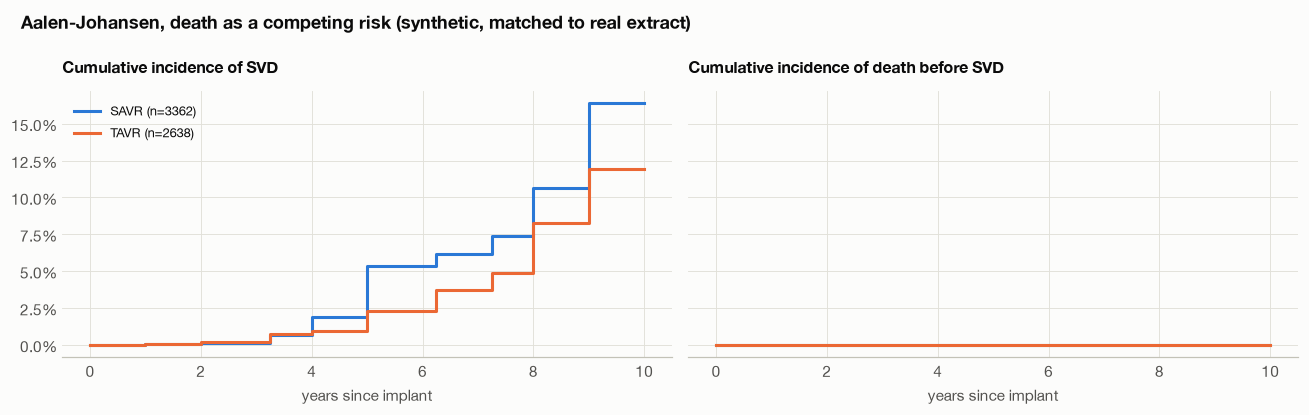

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
grid = np.linspace(0, 10, 41)
groups = tables["patients"].set_index("patient_id").approach.reindex(outcomes.patient_id).fillna("unknown").to_numpy()
for ax, (label, status) in zip(axes, [("SVD", "svd"), ("death before SVD", "death")]):
    for i, g in enumerate([g for g in ["SAVR", "TAVR", "unknown"] if (groups == g).any()]):
        m = groups == g
        s = outcomes.status[m].replace({"svd": "x", "death": "svd"}) if status == "death" else outcomes.status[m]
        curve = [ml.aalen_johansen(outcomes.end_years[m], s, h) for h in grid]
        ax.step(grid, curve, where="post", color=viz.SERIES[i], label=f"{g} (n={m.sum()})")
    ax.set_title(f"Cumulative incidence of {label}", fontsize=10.5)
    ax.set_xlabel("years since implant")
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[0].legend(fontsize=8.5)
fig.suptitle(f"Aalen-Johansen, death as a competing risk ({LABEL})", x=0.02, ha="left", fontweight="bold")
fig.tight_layout()
viz.save(fig, "03_cumulative_incidence")
plt.show()

### How much the label choices matter

The same cohort under each labelling choice, the analogue of comparing a signal before and after each filter.

In [6]:
variants = {"default": {}, "only clinically relevant SVD": dict(endpoint="stage3_or_bvf"), "event dated at interval midpoint": dict(event_time="midpoint"),
            "censor at last contact": dict(censor_at_last_echo=False)}
rows = {}
for name, change in variants.items():
    o = landmarks.build_outcomes(tables, {**LABELS, **change})
    rows[name] = {"SVD": int(o.status.eq("svd").sum()), "death first": int(o.status.eq("death").sum()), "censored": int(o.status.eq("censored").sum()),
                  f"SVD by {VIEW_HORIZON} years (Aalen-Johansen)": ml.aalen_johansen(o.end_years, o.status, VIEW_HORIZON),
                  "median observation (years)": o.end_years.median()}
pd.DataFrame(rows).T.style.format({"SVD": "{:.0f}", "death first": "{:.0f}", "censored": "{:.0f}", f"SVD by {VIEW_HORIZON} years (Aalen-Johansen)": "{:.1%}", "median observation (years)": "{:.1f}"})

,SVD,death first,censored,SVD by 5 years (Aalen-Johansen),median observation (years)
default,183,0,5817,4.2%,3.0
only clinically relevant SVD,183,0,5817,4.2%,3.0
event dated at interval midpoint,183,0,5817,4.2%,3.0
censor at last contact,183,0,5817,4.2%,3.0


## 3. Landmark table

At each landmark time s, every patient still event-free and under observation gets a row. Features use only what was recorded up to s; the outcome is measured from s. So a patient contributes several rows, and later rows carry a longer echo history.

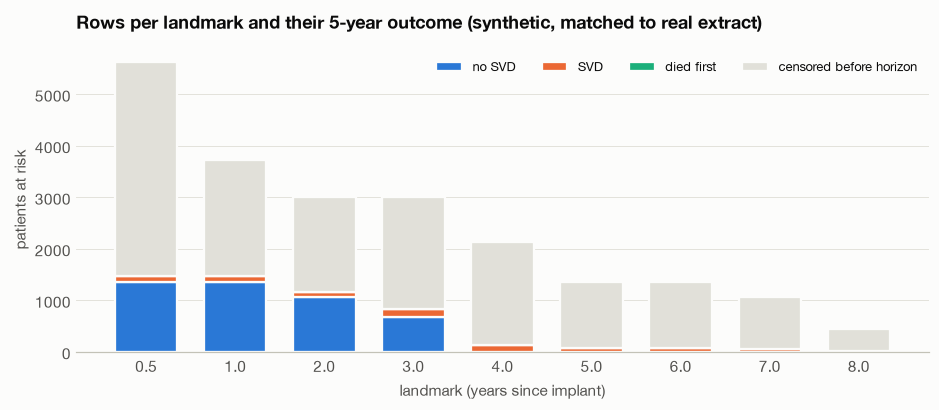

,value
landmark rows,21747
patients,5636
features,42
rows with any missing feature,21747
rows per patient (median / max),4 / 9
rows with SVD within 5 years,849
rows dying first within 5 years,0
rows censored before 5 years,16424
source,simulated
time resolution,"year, unknown"


In [7]:
landmark, _ = landmarks.build_landmark_table(tables, LABELS)
X, meta = ml.feature_matrix(landmark)
assert (meta.time_to_end > 0).all()
avail = pd.DataFrame({lab: ml.outcome_class(meta, VIEW_HORIZON).fillna("censored before horizon").eq(lab).groupby(meta.landmark_years).sum()
                      for lab in ["no SVD", "SVD", "died first", "censored before horizon"]})
fig, ax = plt.subplots(figsize=(10, 3.6))
bottom = np.zeros(len(avail))
colors = [viz.CLASS_COLORS["no SVD"], viz.CLASS_COLORS["SVD"], viz.CLASS_COLORS["died first"], viz.GRID]
for col, color in zip(avail.columns, colors):
    ax.bar(avail.index.astype(str), avail[col], bottom=bottom, color=color, edgecolor=viz.SURFACE, linewidth=1.5, label=col, width=0.7)
    bottom += avail[col].to_numpy()
ax.set_xlabel("landmark (years since implant)")
ax.set_ylabel("patients at risk")
ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, ncol=4, loc="upper right")
ax.set_title(f"Rows per landmark and their {VIEW_HORIZON}-year outcome ({LABEL})")
viz.save(fig, "03_landmark_rows")
plt.show()
ml.summarize(X, meta, VIEW_HORIZON)

## 4. Features

The catalogue lists every feature, the block it belongs to, the direction the literature expects (used as a monotone constraint in the boosted model) and whether it is a **clinical prior**, a predictor established well enough to keep whatever the data say.

In [8]:
catalogue = pd.DataFrame(ml.FEATURES).T.loc[X.columns, ["block", "direction", "prior", "why"]]
catalogue["direction"] = catalogue.direction.map({1: "raises risk", -1: "lowers risk", 0: "not constrained"})
catalogue["missing"] = X.isna().mean().map("{:.0%}".format)
catalogue

,block,direction,prior,why,missing
landmark_years,time,raises risk,True,years since implant at the landmark; SVD hazar...,0%
age_at_implant,patient,lowers risk,True,younger patients degenerate valves faster; the...,100%
male,patient,not constrained,False,direction conflicting across cohorts,7%
bsa_m2,patient,not constrained,False,body size; needed to index EOA,59%
diabetes,patient,raises risk,True,"dysmetabolic calcification, HR 1.33",72%
ckd,patient,raises risk,True,"calcium-phosphate disturbance, early SVD",80%
smoking,patient,raises risk,True,HR 2.28 to 2.58,47%
bicuspid,patient,raises risk,False,"native morphology, younger patients",54%
anticoagulation,patient,lowers risk,True,protects against the thrombotic and pannus pat...,100%
tavr,valve,not constrained,True,SAVR vs TAVR is the comparison of interest,0%


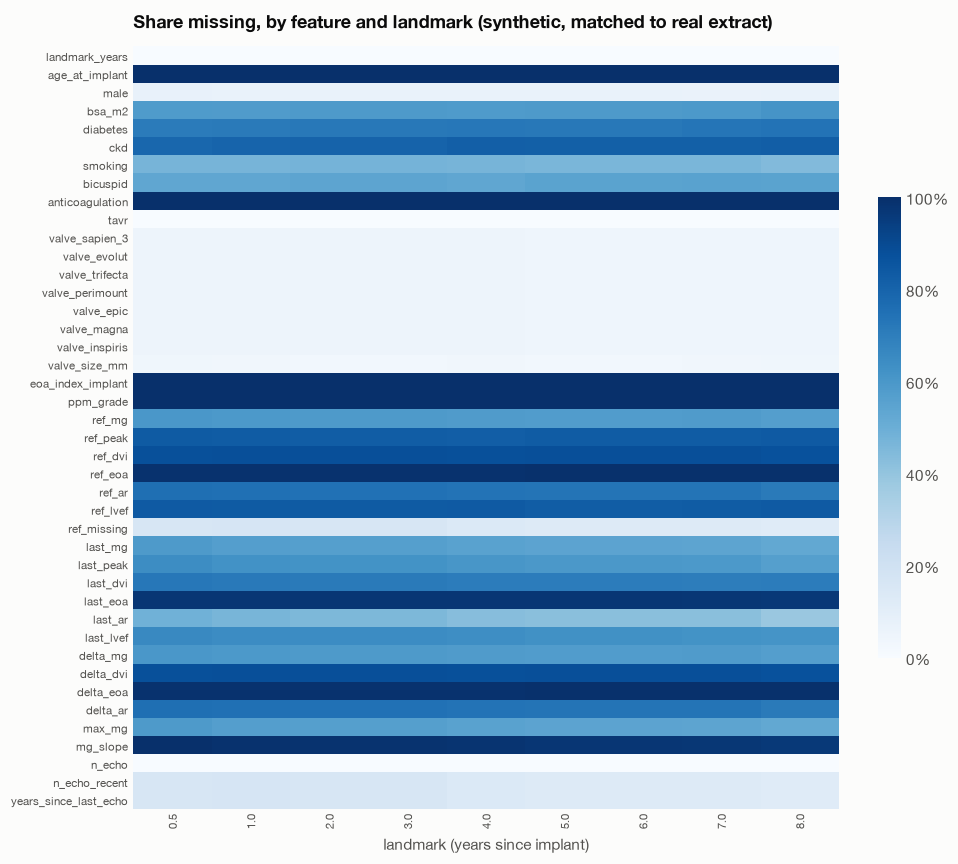

In [9]:
miss = X.isna().groupby(meta.landmark_years).mean().T
fig, ax = plt.subplots(figsize=(9, 9))
im = viz.heatmap(ax, miss, vmin=0, vmax=1, fmt="{:.0%}", annotate=False, cmap="Blues")
ax.set_xlabel("landmark (years since implant)")
fig.colorbar(im, ax=ax, fraction=0.03, format=plt.matplotlib.ticker.PercentFormatter(1)).outline.set_visible(False)
ax.set_title(f"Share missing, by feature and landmark ({LABEL})")
viz.save(fig, "03_missingness")
plt.show()

## 5. Exploring the features

Before any selection, how each feature relates to the outcome at the chosen horizon. Rows censored before the horizon are left out of these views, which is fine for exploration and not for modelling (the models use every row).

### 5a. Distribution by outcome

Features ordered by how well they separate SVD from no SVD on their own (univariable AUC, distance from 0.5).

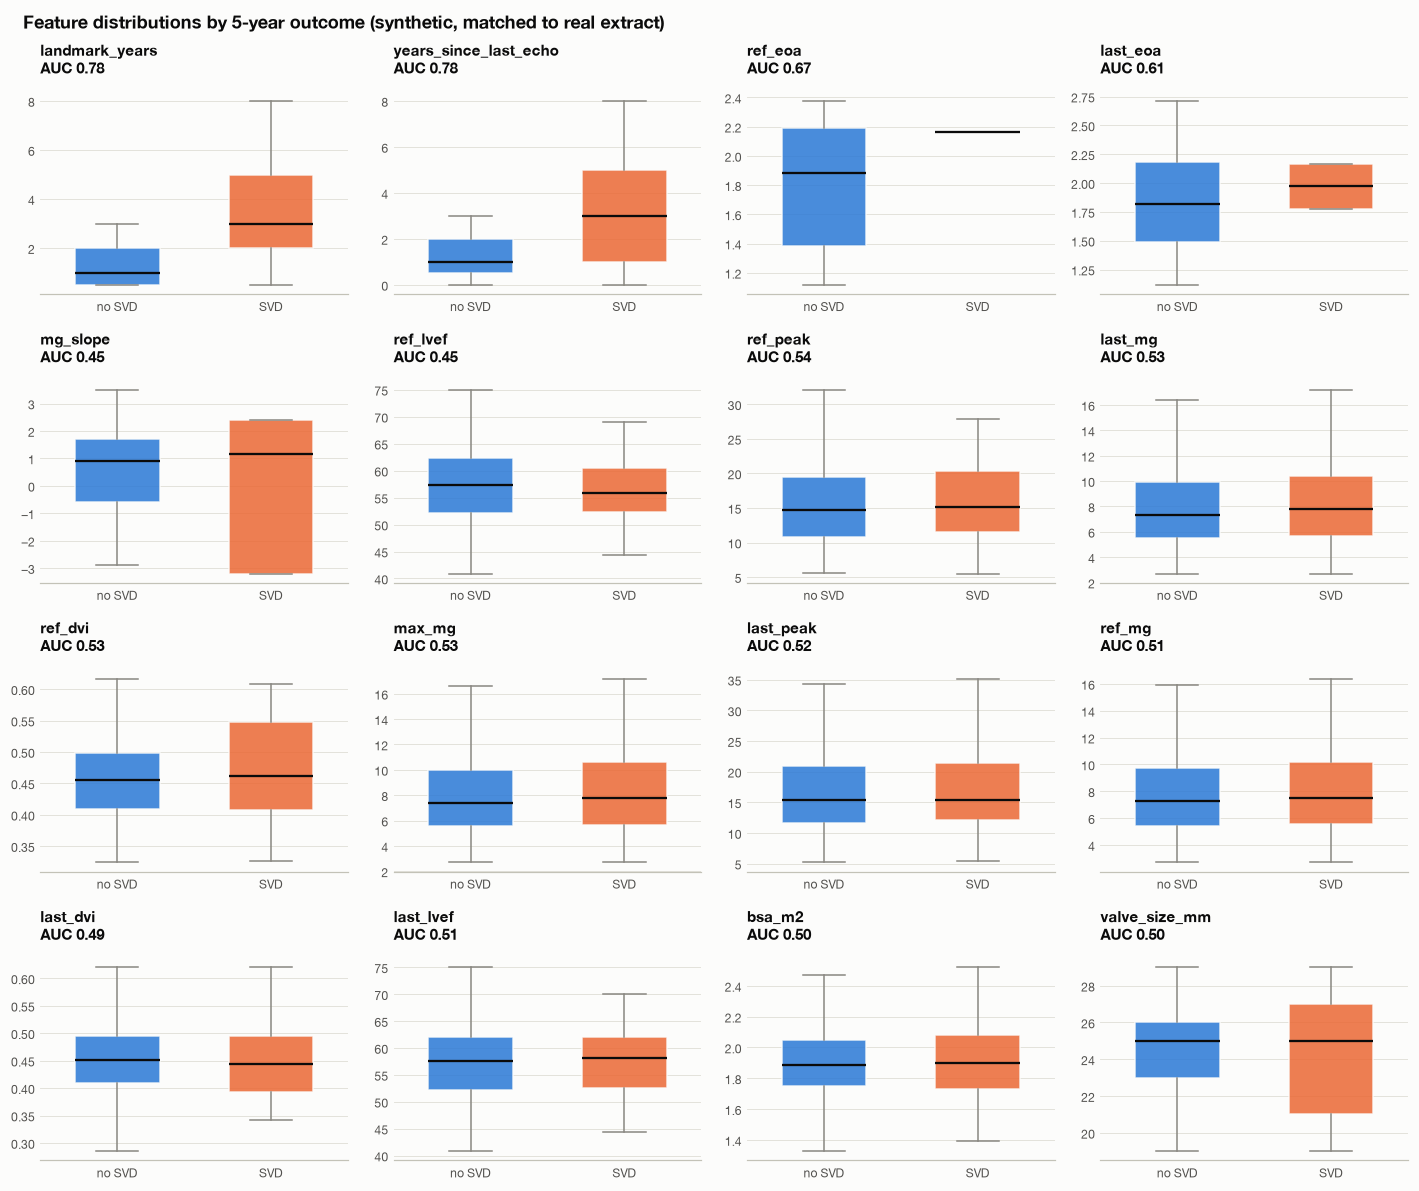

In [10]:
profile = ml.feature_profile(X, meta, VIEW_HORIZON)
ranked = profile["univariable AUC"].sub(0.5).abs().sort_values(ascending=False).index.tolist()
classes = ml.outcome_class(meta, VIEW_HORIZON)
show = [f for f in ranked if X[f].nunique() > 5 and X[f].quantile(0.9) > X[f].quantile(0.1)][:16]
fig, axes = plt.subplots(4, 4, figsize=(13, 11))
for ax, f in zip(axes.flat, show):
    viz.box_by_class(ax, X[f], classes, f"{f}\nAUC {profile.loc[f, 'univariable AUC']:.2f}")
for ax in axes.flat[len(show):]:
    ax.axis("off")
fig.suptitle(f"Feature distributions by {VIEW_HORIZON}-year outcome ({LABEL})", x=0.02, ha="left", fontweight="bold")
fig.tight_layout()
viz.save(fig, "03_distributions_by_outcome")
plt.show()

### 5b. Mean profile by outcome

Each feature standardised to mean 0 and SD 1, then averaged within each outcome group. Red means the group sits above the cohort average. Binary features are included here.

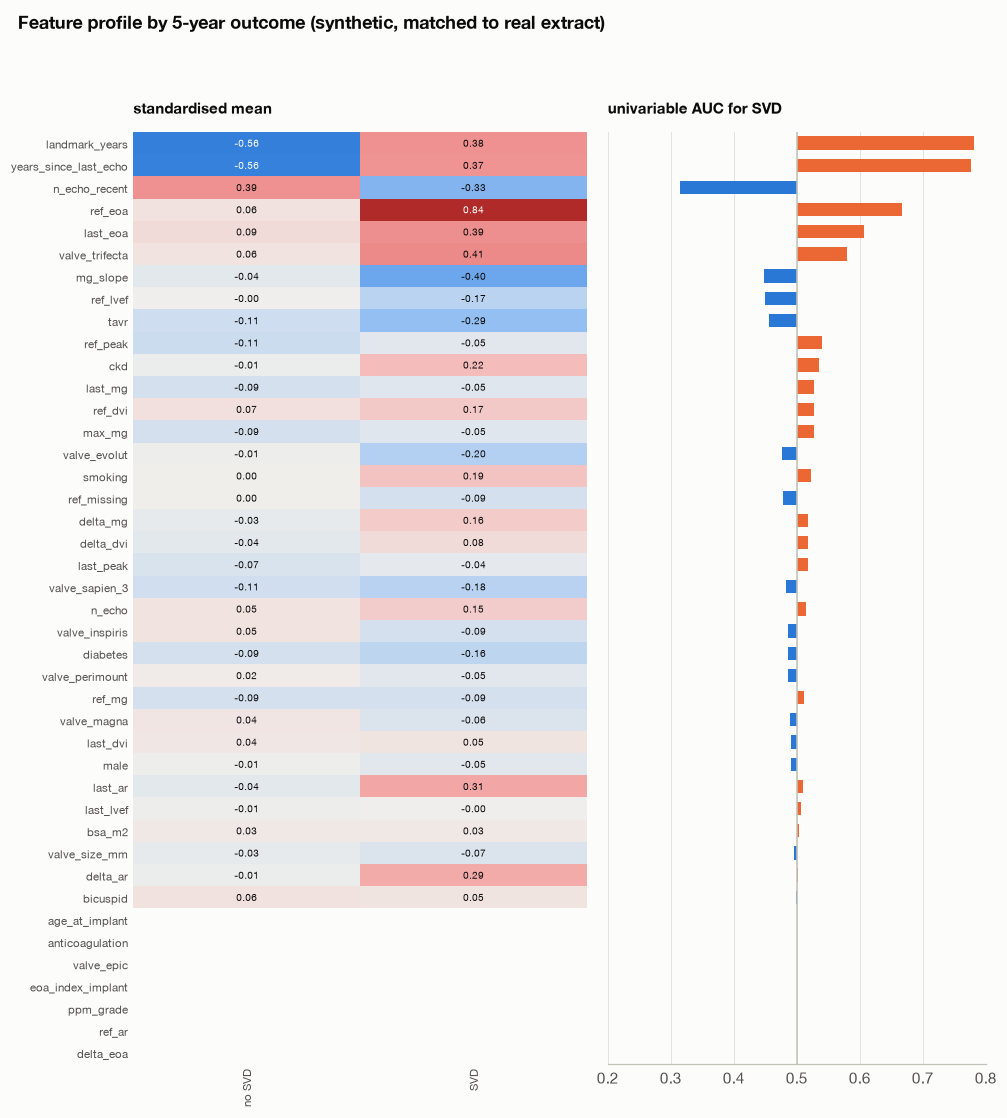

In [11]:
order = [c for c in ["no SVD", "SVD", "died first"] if c in profile]
prof = profile.loc[ranked, order]
fig, axes = plt.subplots(1, 2, figsize=(10, 11), gridspec_kw=dict(width_ratios=[1.2, 1], wspace=0.05), sharey=True)
viz.heatmap(axes[0], prof, vmin=-0.8, vmax=0.8)
axes[0].set_title("standardised mean", fontsize=10)
auc = profile.loc[ranked, "univariable AUC"]
axes[1].barh(range(len(auc)), auc - 0.5, left=0.5, color=[viz.SERIES[1] if v > 0.5 else viz.SERIES[0] for v in auc], height=0.6)
axes[1].axvline(0.5, color=viz.AXIS, linewidth=1)
axes[1].set_xlim(0.2, 0.8)
axes[1].set_title("univariable AUC for SVD", fontsize=10)
axes[1].grid(axis="y", visible=False)
fig.suptitle(f"Feature profile by {VIEW_HORIZON}-year outcome ({LABEL})", x=0.02, ha="left", fontweight="bold")
viz.save(fig, "03_feature_profile")
plt.show()

### 5c. Correlation between features

Spearman correlation. Near-duplicates (peak and mean gradient, latest and maximum gradient, the two LVEF readings) are what the correlation filter removes; moderately correlated pairs such as reference and latest gradient carry different information (baseline vs change) and are kept.

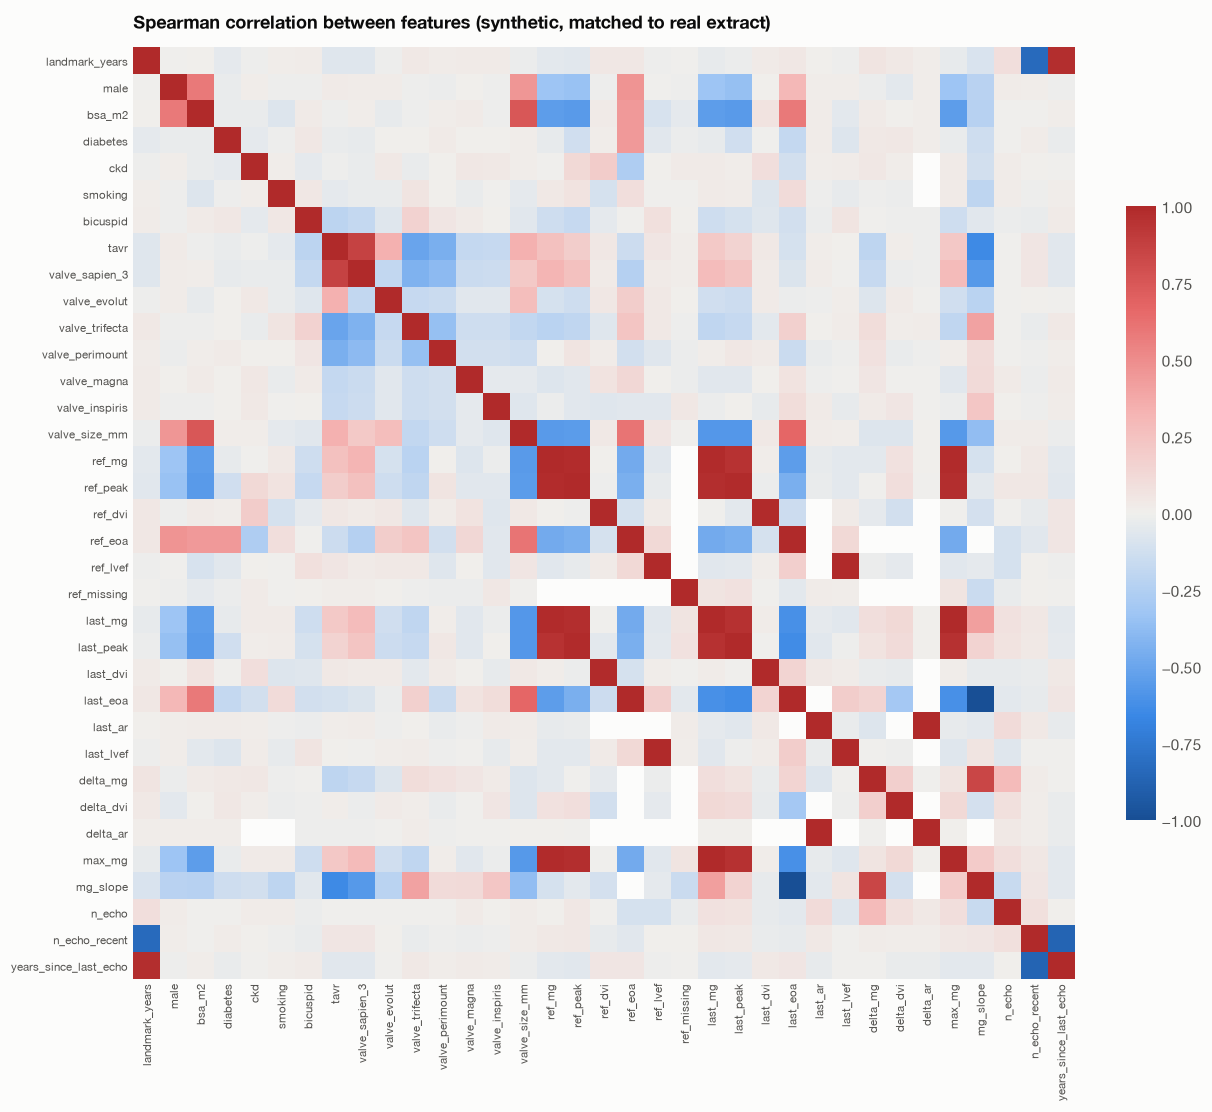

rho
last_ar        delta_ar               1.000000
last_eoa       mg_slope              -1.000000
ref_eoa        last_eoa               1.000000
ref_lvef       last_lvef              1.000000
last_mg        max_mg                 0.996542
ref_dvi        last_dvi               0.992151
ref_mg         max_mg                 0.989475
ref_peak       last_peak              0.988336
ref_mg         last_mg                0.985650
               ref_peak               0.979443
ref_peak       max_mg                 0.974011
               last_mg                0.970366
landmark_years years_since_last_echo  0.969598
last_mg        last_peak              0.956864
last_peak      max_mg                 0.955911

In [12]:
corr = X.loc[:, X.nunique() > 1].corr(method="spearman")
fig, ax = plt.subplots(figsize=(12, 11))
im = viz.heatmap(ax, corr, annotate=False)
fig.colorbar(im, ax=ax, fraction=0.03).outline.set_visible(False)
ax.set_title(f"Spearman correlation between features ({LABEL})")
viz.save(fig, "03_correlation")
plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack()
pairs[pairs.abs() > 0.7].sort_values(key=abs, ascending=False).rename("rho").to_frame().head(15)

### 5d. Principal components

A two-dimensional view of all features after median filling and scaling, coloured by outcome. For looking only: the models use the features themselves, because principal components cannot be explained to a clinician.

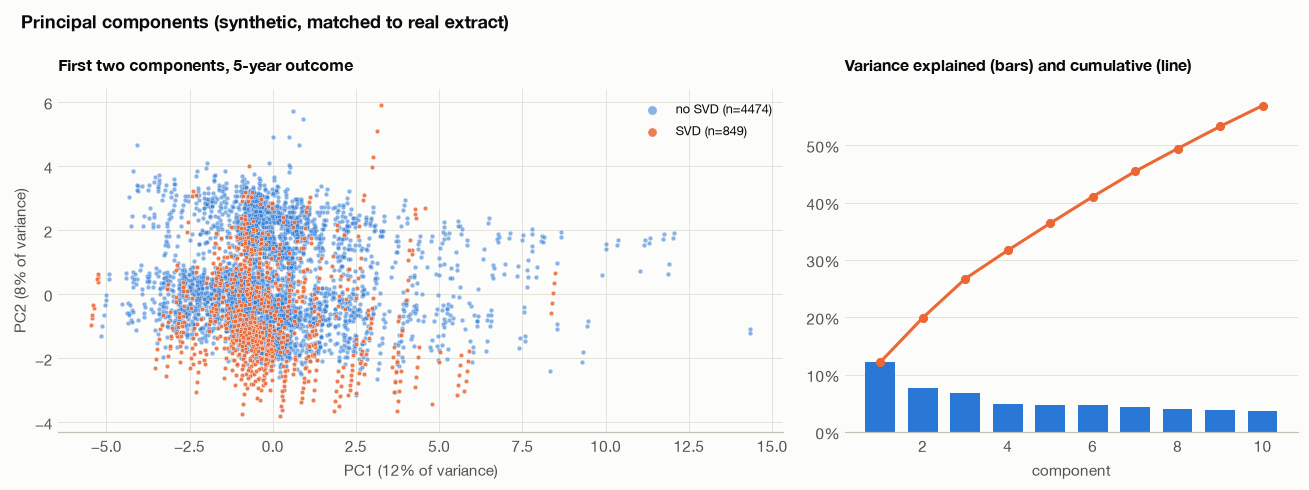

In [13]:
coords, explained = ml.pca_view(X)
known = classes.notna().to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw=dict(width_ratios=[1.6, 1]))
viz.pca_scatter(axes[0], coords[known], classes[known].reset_index(drop=True), explained)
axes[0].set_title(f"First two components, {VIEW_HORIZON}-year outcome", fontsize=10.5)
axes[1].bar(range(1, len(explained) + 1), explained, color=viz.SERIES[0], width=0.7)
axes[1].plot(range(1, len(explained) + 1), np.cumsum(explained), color=viz.SERIES[1], marker="o", markersize=5)
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[1].set_xlabel("component")
axes[1].set_title("Variance explained (bars) and cumulative (line)", fontsize=10.5)
axes[1].grid(axis="x", visible=False)
fig.suptitle(f"Principal components ({LABEL})", x=0.02, ha="left", fontweight="bold")
fig.tight_layout()
viz.save(fig, "03_pca")
plt.show()

## 6. Feature selection (switchable)

Four filters, run on the training rows only so the test set stays unseen:

1. **missing**: more than `max_missing` of rows empty
2. **constant**: one value on more than `max_mode_share` of rows
3. **correlated**: Spearman above `max_corr` (0.95, so only near-duplicates such as peak and mean gradient); the clinical prior wins, otherwise the feature listed first
4. **stability**: an L1-penalised discrete-time SVD model on `n_boot` random halves of the training patients; features chosen in fewer than `min_freq` of fits are flagged

Clinical priors are kept unless they are mostly empty or constant (`keep_priors`).

By default the model uses a **fixed clinical list** (`SELECTION["mode"] = "fixed"`, `ml.FIXED_FEATURES`): time since implant, TAVR or surgery, valve size, Trifecta, first gradient after the implant (and whether it is missing), latest gradient, and the change between them. These are the valve features the SVD literature names and that the real extract records. Automatic selection chose different features on different random training sets (BSA in one run, bicuspid in another) and so added run-to-run noise; the table still shows what it would have picked. Set `mode` to `"auto"` to use the four filters instead.

Selection is on by default (`SELECTION["enabled"] = True`). With it off nothing is dropped: the table shows what the filters would do, and every feature goes to the model.

Before the four filters, whole blocks listed in `drop_blocks` are removed. The default drops the **surveillance** block (number of echoes, recent echoes, years since the last echo). These describe how often a valve was looked at, not how it is ageing, and they differ between hospitals. With them in, the boosted model learned the synthetic cohort's surveillance pattern and ranked the real extract worse than chance (5-year AUC 0.45); without them it reached 0.80.

In [14]:
train = meta.implant_year.le(SPLIT_YEAR).to_numpy()
test = ~train
report = ml.select_features(X[train], meta[train], SELECTION)
features_used = report.index[report.used].tolist()
display(pd.Series({"selection applied": SELECTION["enabled"], "features in": len(report), "features used": len(features_used),
                   "would be kept if applied": int(report.would_keep.sum())}, name="value").to_frame())
report.sort_values(["would_keep", "stability"], ascending=False).style.format({"missing": "{:.0%}", "stability": "{:.0%}"}, na_rep="")

,value
selection applied,True
features in,42
features used,8
would be kept if applied,9


,block,prior,missing,flag,stability,would_keep,used,fixed,decision
landmark_years,time,True,0%,,100%,True,True,True,fixed list; automatic selection would keep
valve_trifecta,valve,False,5%,,100%,True,True,True,fixed list; automatic selection would keep
delta_mg,trajectory,True,58%,,80%,True,True,True,fixed list; automatic selection would keep
tavr,valve,True,0%,,72%,True,True,True,fixed list; automatic selection would keep
valve_inspiris,valve,False,5%,,70%,True,False,False,not in fixed list; automatic selection would keep
bsa_m2,patient,False,58%,,65%,True,False,False,not in fixed list; automatic selection would keep
smoking,patient,True,47%,,62%,True,False,False,not in fixed list; automatic selection would keep
valve_size_mm,valve,True,3%,unstable in bootstrap,40%,True,True,True,fixed list; automatic selection would keep
ref_mg,reference echo,True,58%,unstable in bootstrap,30%,True,True,True,fixed list; automatic selection would keep
male,patient,False,7%,unstable in bootstrap,55%,False,False,False,not in fixed list; automatic selection would drop: unstable in bootstrap


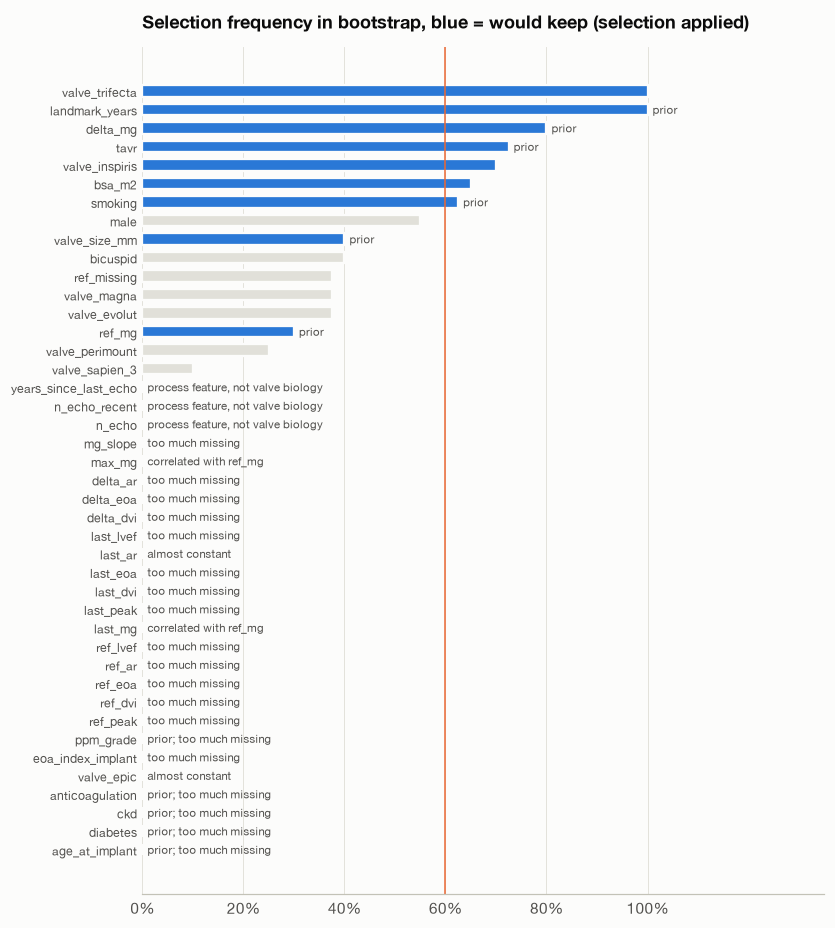

In [15]:
r = report.sort_values("stability", na_position="first")
fig, ax = plt.subplots(figsize=(8, 10))
colors = [viz.SERIES[0] if k else viz.GRID for k in r.would_keep]
ax.barh(r.index, r.stability.fillna(0), color=colors, height=0.62, edgecolor=viz.SURFACE, linewidth=1.5)
ax.axvline(SELECTION["min_freq"], color=viz.SERIES[1], linewidth=1)
for i, (_, row) in enumerate(r.iterrows()):
    note = "prior" if row.prior else ""
    if row.flag and not row.flag.startswith("unstable"):
        note = (note + "; " if note else "") + row.flag.split(" (")[0]
    if note:
        ax.text(min(row.stability if pd.notna(row.stability) else 0, 1) + 0.01, i, note, va="center", fontsize=7.5, color=viz.INK_SECONDARY)
ax.set_xlim(0, 1.35)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8)
state = "applied" if SELECTION["enabled"] else "not applied"
ax.set_title(f"Selection frequency in bootstrap, blue = would keep (selection {state})")
viz.save(fig, "03_feature_selection")
plt.show()

## 7. Split and person-period rows

**Split.** Temporal, by implant year: valves implanted up to `SPLIT_YEAR` train the model, later valves test it. A patient's rows are never on both sides.

**Person-period rows.** Each landmark row becomes one row per year of follow-up up to the longest horizon, with target 0 (nothing), 1 (SVD) or 2 (death). A censored row keeps only its fully observed years. This is the discrete-time form the models in notebook 04 consume.

In [16]:
assert not set(meta.patient_id[train]) & set(meta.patient_id[test])
H = max(LABELS["horizons"])
Xe, target, groups = ml.expand_discrete(X[train], meta[train], H)
display(pd.DataFrame({name: {"landmark rows": int(m.sum()), "patients": meta.patient_id[m].nunique(),
                             "patients with SVD": meta.patient_id[m & meta.status.eq("svd")].nunique(),
                             "patients dying first": meta.patient_id[m & meta.status.eq("death")].nunique()}
                      for name, m in [(f"train (implant up to {SPLIT_YEAR})", train), (f"test (implant after {SPLIT_YEAR})", test)]}).T)
pd.crosstab(Xe.interval, pd.Series(target, name="target").map({0: "nothing", 1: "SVD", 2: "death"}), margins=True, margins_name="total").rename_axis(index="year after landmark (train)")

,landmark rows,patients,patients with SVD,patients dying first
train (implant up to 2018),15879,4021,146,0
test (implant after 2018),5868,1615,37,0


target,SVD,nothing,total
year after landmark (train),,,
1,146,13726,13872
2,142,10575,10717
3,139,8213,8352
4,126,5803,5929
5,105,3688,3793
6,59,2449,2508
7,48,1390,1438
8,37,650,687
total,802,46494,47296


In [17]:
bundle = dict(X=X, meta=meta, landmark=landmark, outcomes=outcomes, train=train, test=test, features_used=features_used,
              selection_report=report, labels=LABELS, selection=SELECTION, source=SOURCE, preset=PRESET, seed=SEED, split_year=SPLIT_YEAR, label=LABEL)
(OUT / "model_input.pkl").write_bytes(pickle.dumps(bundle))
from pipeline import ledger
(OUT / ledger.CONFIG_NAME).unlink(missing_ok=True)
ledger.update_run_config(OUT, "data", dict(
    source=SOURCE, preset=PRESET, seed=SEED, n_patients=N_PATIENTS, split_year=SPLIT_YEAR, train_like_real=TRAIN_LIKE_REAL, label=LABEL,
    features_used=features_used, train_rows=int(train.sum()), test_rows=int(test.sum()),
    train_events=int(meta.patient_id[train & meta.status.eq("svd").to_numpy()].nunique()),
    test_events=int(meta.patient_id[test & meta.status.eq("svd").to_numpy()].nunique())))
ledger.update_run_config(OUT, "labels", LABELS)
ledger.update_run_config(OUT, "selection", SELECTION)
ledger.update_run_config(OUT, "matching", MATCH if SOURCE == "synthetic" and TRAIN_LIKE_REAL else {})
pd.Series({"written": str((OUT / "model_input.pkl").relative_to(ROOT)), "settings": str((OUT / ledger.CONFIG_NAME).relative_to(ROOT)), "rows": len(X), "features used": len(features_used)}, name="value").to_frame()

,value
written,data/processed/runs/final/model_input.pkl
settings,data/processed/runs/final/run_config.json
rows,21747
features used,8
